(mmm_prior_sensitivity)=
# Prior Sensitivity in the MMM Workflow

This case study uses the synthetic, confounded data from PyMC-Marketing's
{ref}`ROAS lift-test case study <mmm_roas>`.
The goal is not to introduce every MMM diagnostic, but to show one practical workflow:

1. fit an initial MMM with a stakeholder-informed **business prior** on ROAS,
2. distinguish sensitivity in internal parameters from sensitivity in the ROAS estimate,
3. communicate the decision-relevant conflict instead of tuning it away, and
4. add lift-test evidence to see whether the conflict and prior sensitivity disappear.

We keep the synthetic true ROAS hidden until the end, so the modeling decisions are based on diagnostics and domain assumptions rather than the answer key.


## Prepare Notebook


In [1]:
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior
from xarray import DataArray

from pymc_marketing.hsgp_kwargs import HSGPKwargs
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore", category=FutureWarning)
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

In [2]:
seed = sum(map(ord, "mmm_prior_sensitivity_roas"))
rng = np.random.default_rng(seed=seed)

biz_prior_x1 = pz.distributions.Normal(100, 20)
biz_prior_x2 = pz.distributions.Normal(150, 50)

## Data

The observed data contain 2.5 years of weekly spend for two media channels,
`x1` and `x2`, plus the target `y`. The data-generating process includes an
unobserved confounder, `z`, that affects spend and sales. A model that cannot
observe `z` can predict sales well while assigning the wrong ROAS to the
channels.


In [3]:
data_path = data_dir / "mmm_roas_data.csv"
raw_df = pd.read_csv(data_path, parse_dates=["date"])
model_df = raw_df.filter(["date", "x1", "x2", "y"]).copy()

channel_columns = ["x1", "x2"]
target_column = "y"
date_column = "date"
X = model_df.drop(columns=[target_column])
y = model_df[target_column]

In [4]:
model_df.head()

,date,x1,x2,y
0,2021-10-02,0.646554,0.336188,199.329637
1,2021-10-09,1.411917,0.203931,371.237041
2,2021-10-16,0.837610,0.024026,272.215933
3,2021-10-23,0.973612,0.120257,291.104040
4,2021-10-30,1.415985,0.084630,386.243000


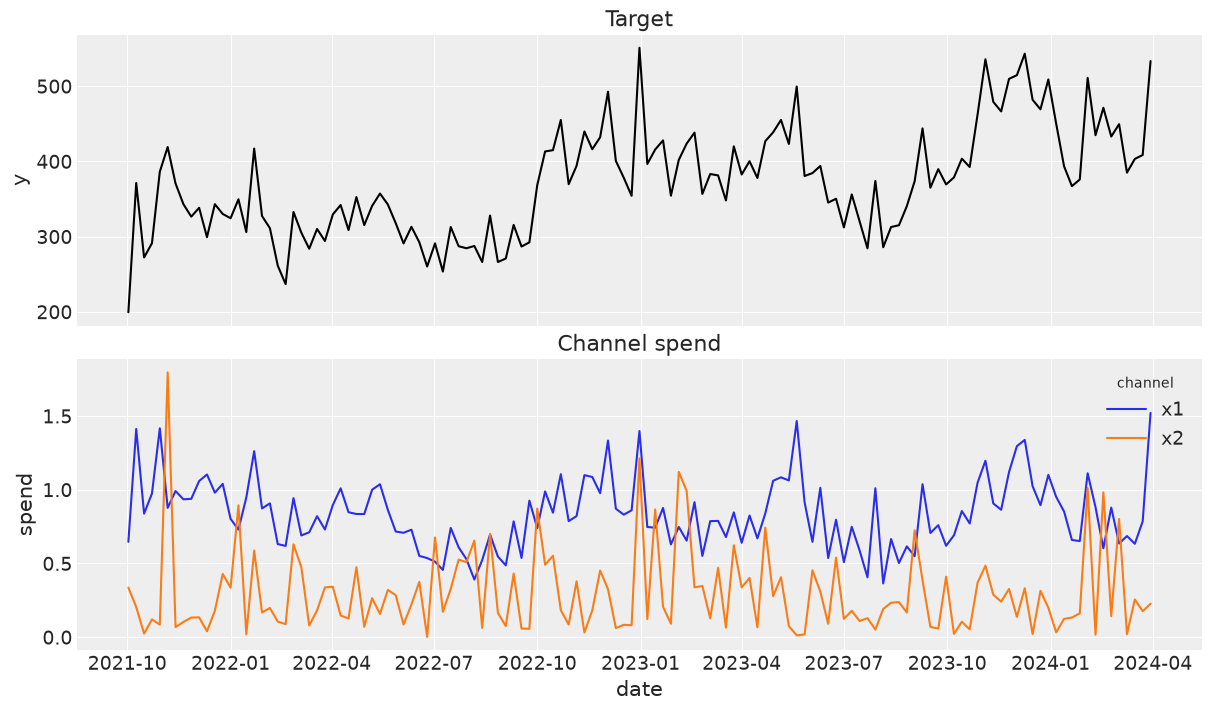

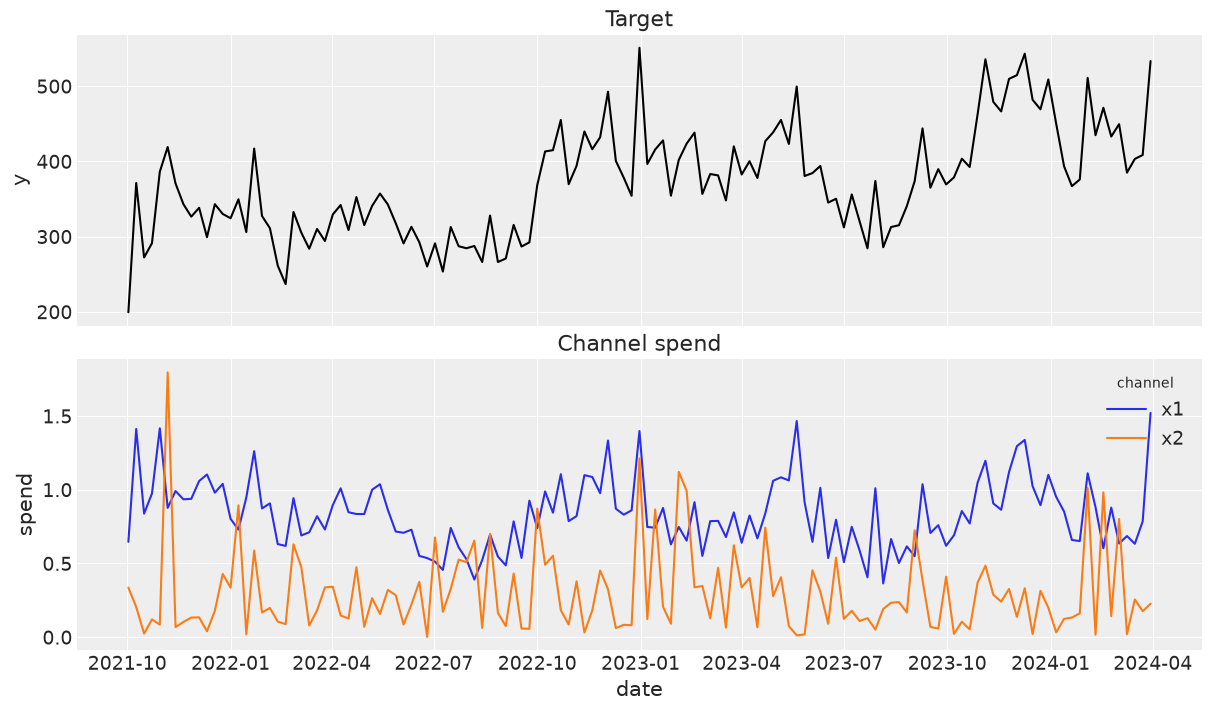

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, layout="constrained")
sns.lineplot(x="date", y="y", data=model_df, color="black", ax=axes[0])
axes[0].set_title("Target")
spend_long = model_df.melt(
    id_vars=["date"],
    value_vars=["x1", "x2"],
    var_name="channel",
    value_name="spend",
)
sns.lineplot(x="date", y="spend", hue="channel", data=spend_long, ax=axes[1])
axes[1].set_title("Channel spend")
fig

## 1. Initial Model: Business Prior and Observational Data

Stakeholders expect ROAS near 100 for `x1` and 150 for `x2`. We call these
expectations the **business prior**: functionally, they express prior
understanding before fitting the MMM. Because ROAS is a derived quantity rather
than a free model parameter, PyMC-Marketing represents this prior with
`add_cost_per_target_calibration`, an extra model factor on the implied ROAS.

The initial model also has weakly informative media priors and a flexible
time-varying baseline whose amplitude prior allows substantial non-media
movement.


In [6]:
business_prior_df = pd.DataFrame(
    {
        "channel": ["x1", "x2"],
        "roas": [100, 150],
        "sigma": [20, 50],
    }
)

baseline_model_config = {
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.5)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": HSGPKwargs(
        m=50, L=None, eta_lam=1.0, ls_mu=5.0, ls_sigma=10.0, cov_func=None
    ),
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=2, beta=2, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=1, dims="channel"),
}

sampler_config = {
    "tune": 1_000,
    "chains": 6,
    "cores": 6,
    "draws": 2_000,
    "random_seed": rng,
    "nuts": {"adaptation": "draw_diag", "target_accept": 0.94},
}
lift_sampler_config = {
    **sampler_config,
    "nuts": {"adaptation": "draw_diag", "target_accept": 0.96},
}

In [7]:
business_prior_df

,channel,roas,sigma
0,x1,100,20
1,x2,150,50


In [8]:
def build_mmm(model_config):
    return MMM(
        adstock=GeometricAdstock(l_max=4),
        saturation=LogisticSaturation(),
        date_column=date_column,
        channel_columns=channel_columns,
        target_column=target_column,
        time_varying_intercept=True,
        time_varying_media=False,
        yearly_seasonality=5,
        model_config=model_config,
    )


def finish_model(mmm, X, y, sampler_config, business_prior_df=None):
    mmm.add_original_scale_contribution_variable(
        var=[
            "channel_contribution",
            "fourier_contribution",
            "intercept_contribution",
        ]
    )
    mmm.add_cost_per_target_calibration(
        data=X,
        calibration_data=business_prior_df,
        name_prefix="business_prior",
        target_column="roas",
        target_per_cost=True,
    )
    mmm.fit(X, y, **sampler_config)
    mmm.sample_posterior_predictive(
        X, extend_idata=True, combined=True, random_seed=rng
    )
    # The sensitivity analysis
    with mmm.model:
        pm.compute_log_likelihood(mmm.idata)
        pm.stats.compute_log_prior(mmm.idata)

    # Internally, the business prior is expressed as a likelihood.
    # Move it to log_prior so it is not double-counted in sensitivity checks.
    mmm.idata["log_prior"]["business_prior"] = mmm.idata["log_likelihood"][
        "business_prior"
    ]
    del mmm.idata["log_likelihood"]["business_prior"]
    mmm.idata["posterior"]["ROAS"] = (
        mmm.incrementality.compute_incremental_contribution("all_time")
        / mmm.idata["constant_data"]["channel_data"].sum("date")
    )
    return mmm


def roas_summary(mmm):
    summary = az.summary(
        mmm.idata,
        var_names=["ROAS"],
        ci_prob=0.94,
        ci_kind="hdi",
    )
    interval_columns = [
        column for column in summary.columns if column.startswith("hdi")
    ]
    return (
        summary[["mean", "sd", *interval_columns]]
        .apply(pd.to_numeric, errors="coerce")
        .round(1)
    )


def convergence_summary(mmm):
    diagnostics = az.summary(
        mmm.idata,
        var_names=[var.name for var in mmm.model.free_RVs],
        kind="diagnostics",
    )
    numeric_diagnostics = diagnostics[["r_hat", "ess_bulk", "ess_tail"]].apply(
        pd.to_numeric, errors="coerce"
    )
    return pd.Series(
        {
            "divergences": int(mmm.idata["sample_stats"]["diverging"].sum().item()),
            "max_r_hat": numeric_diagnostics["r_hat"].max(),
            "min_ess_bulk": numeric_diagnostics["ess_bulk"].min(),
            "min_ess_tail": numeric_diagnostics["ess_tail"].min(),
        },
        name="diagnostic",
        dtype=float,
    ).round(3)

In [9]:
business_mmm = build_mmm(baseline_model_config)
business_mmm.build_model(X, y)
business_mmm = finish_model(
    business_mmm,
    X,
    y,
    sampler_config=sampler_config,
    business_prior_df=business_prior_df,
)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, y_sigma]


Output()

Output()

Sampling: [business_prior, y]


Output()

Output()

Output()

### Model Diagnostics

Before interpreting ROAS, we verify that the fit has no divergences, a maximum R-hat below 1.01, and adequate bulk and tail effective sample sizes.


In [10]:
convergence_summary(business_mmm)

divergences        0.0
max_r_hat          1.0
min_ess_bulk    4342.0
min_ess_tail    5173.0
Name: diagnostic, dtype: float64

Before focusing on ROAS, we inspect how the model decomposes the observed target into channel, baseline, and seasonal contributions. This provides a first check that the fitted components reproduce the main temporal structure in the data.


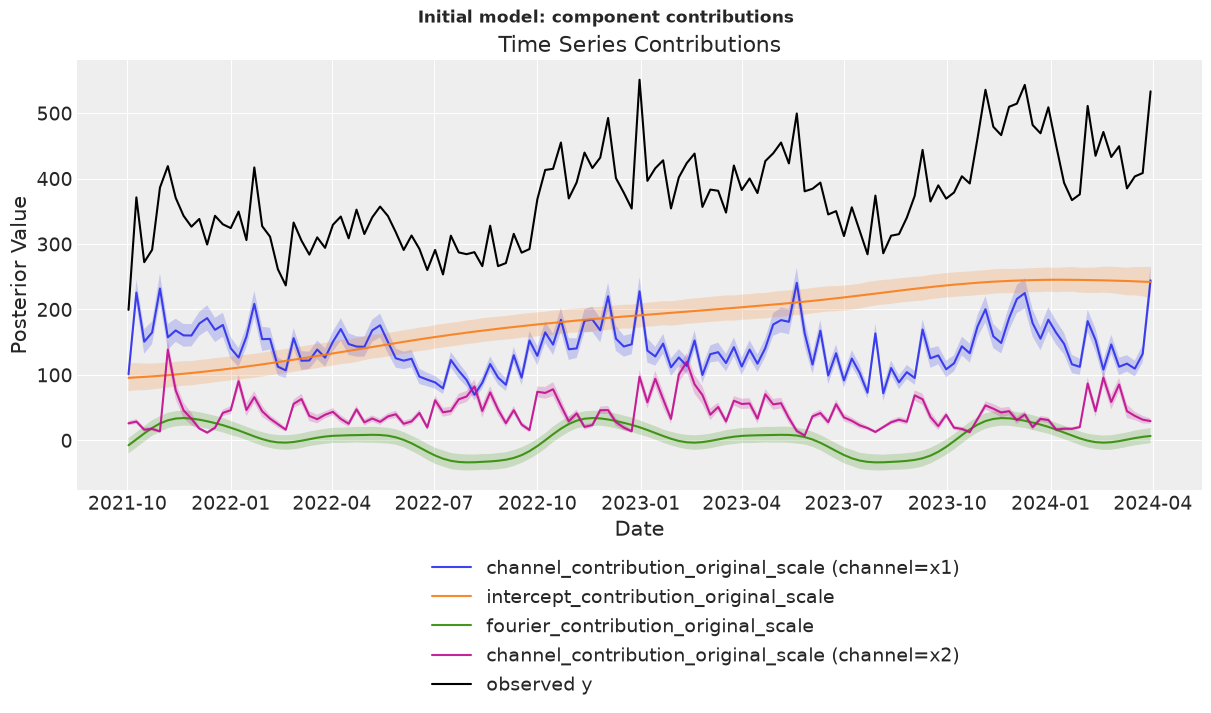

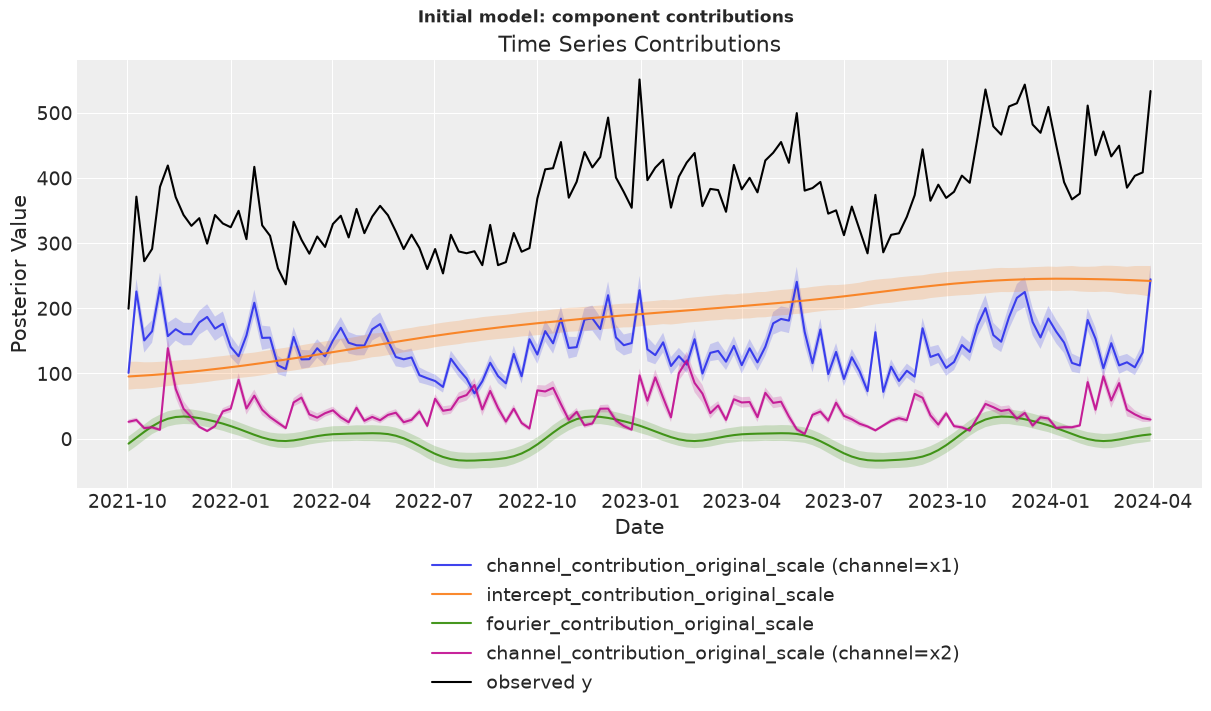

In [11]:
# We will reuse this later
def contribution_plot(mmm, model_df, title):
    fig, axes = mmm.plot.contributions_over_time(
        var=[
            "channel_contribution_original_scale",
            "intercept_contribution_original_scale",
            "fourier_contribution_original_scale",
        ],
        dims={"channel": ["x1", "x2"]},
        combine_dims=True,
        hdi_prob=0.94,
        figsize=(12, 7),
    )
    sns.lineplot(
        x="date",
        y="y",
        data=model_df,
        color="black",
        label="observed y",
        ax=axes[0, 0],
    )
    legend = axes[0, 0].get_legend()
    legend.set_bbox_to_anchor((0.8, -0.12))
    fig.suptitle(title, fontweight="bold")
    return fig


contribution_plot(business_mmm, model_df, "Initial model: component contributions")

Our reporting target is all-time channel ROAS. We therefore compare its posterior distribution with the stakeholder-informed business prior before formally measuring how sensitive that posterior is to the different sources of information.


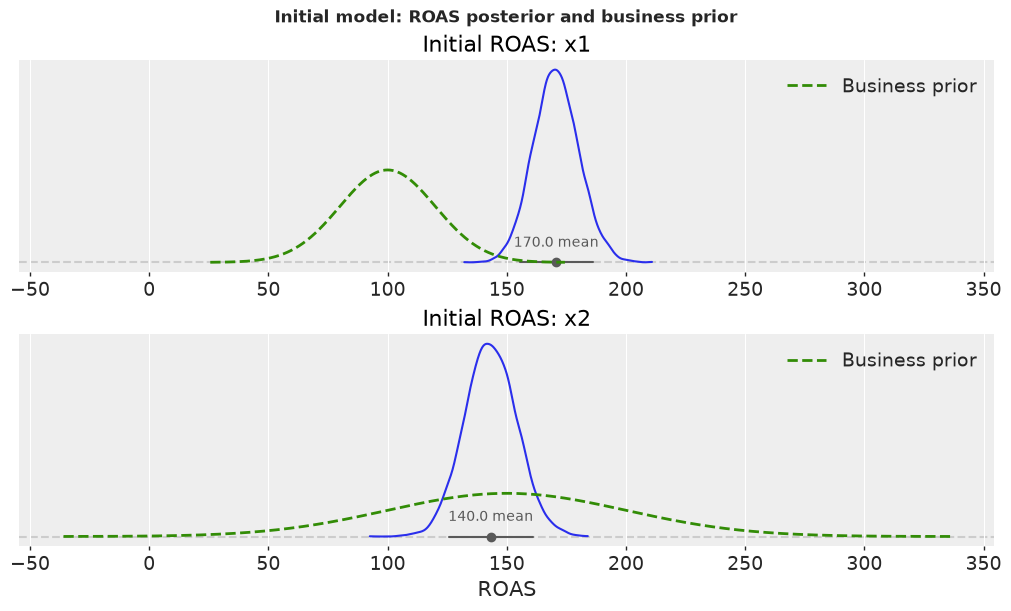

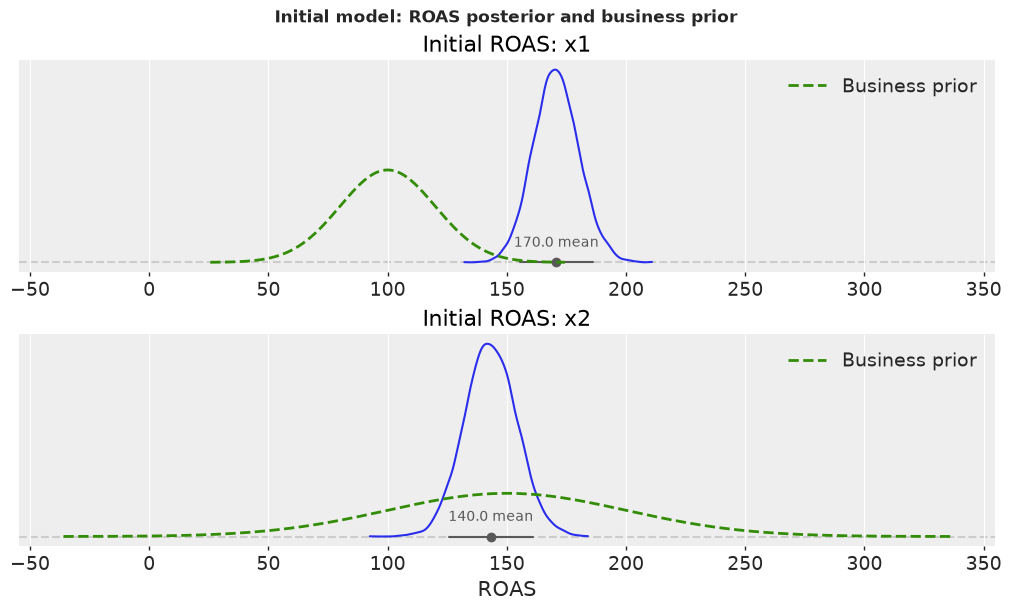

In [12]:
plot_collection = azp.plot_dist(
    business_mmm.idata["posterior"]["ROAS"].to_dataset(name="roas"),
    col_wrap=1,
    figure_kwargs={
        "figsize": (10, 6),
        "sharex": True,
        "layout": "constrained",
    },
)
fig = plot_collection.viz["/"]["figure"].values.item()
axes = fig.axes
biz_prior_x1.plot_pdf(color="C2", linestyle="--", linewidth=2, ax=axes[0], legend=None)
biz_prior_x2.plot_pdf(color="C2", linestyle="--", linewidth=2, ax=axes[1], legend=None)
axes[0].lines[-1].set_label("Business prior")
axes[1].lines[-1].set_label("Business prior")
axes[0].legend(loc="upper right")
axes[0].set(title="Initial ROAS: x1")
axes[1].legend(loc="upper right")
axes[1].set(title="Initial ROAS: x2", xlabel="ROAS")
fig.suptitle("Initial model: ROAS posterior and business prior", fontweight="bold")
fig

### Prior Sensitivity Check

We next assess the prior and likelihood sensitivity of ROAS. This shows how strongly each component influences the reported estimates and helps identify unexpectedly influential priors.

To answer this, we use **power-scaling sensitivity analysis** ([Kallioinen et al., 2024](https://link.springer.com/article/10.1007/s11222-023-10366-5)), a diagnostic that evaluates how much influence each prior or likelihood component exerts on the posterior by scaling its log-density with a power parameter $\alpha$.

The standard posterior is

$$p(\theta \mid y) \propto p(y \mid \theta) \, p(\theta)$$

and we consider two power-scaling variants:

- **Prior sensitivity**: $p(\theta \mid y) \propto p(y \mid \theta) \, p(\theta)^\alpha$
- **Likelihood sensitivity**: $p(\theta \mid y) \propto p(y \mid \theta)^\alpha \, p(\theta)$

When $\alpha = 1$, the model is fitted to the original specification. When $\alpha < 1$, the scaled component is weakened; when $\alpha > 1$, it is amplified. By examining how posterior quantities of interest change as we perturb $\alpha$, we can see how tension between the priors and likelihood affects the estimates we want to report.

The following figure illustrates the effect of power scaling on a standard Normal distribution.


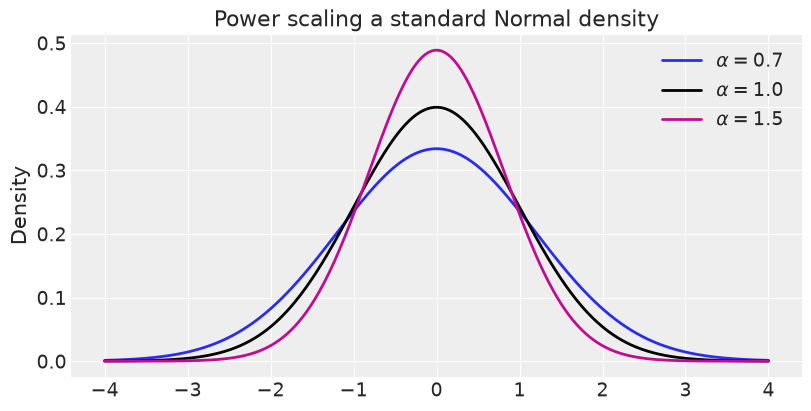

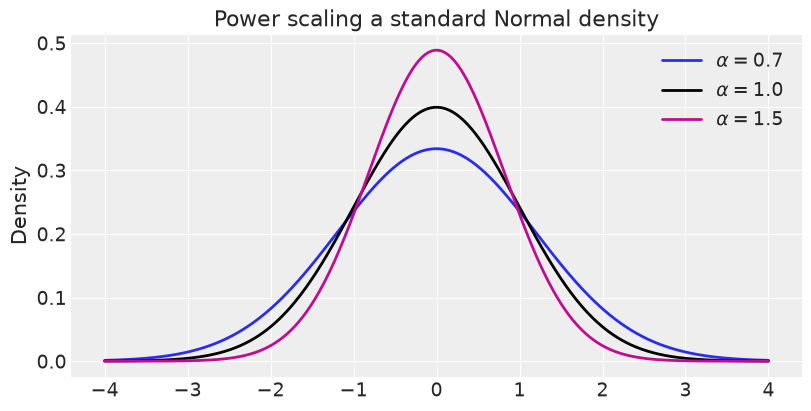

In [13]:
grid = np.linspace(-4, 4, 500)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for alpha, color in [(0.7, "C0"), (1.0, "black"), (1.5, "C3")]:
    sigma = 1 / np.sqrt(alpha)
    density = np.exp(-0.5 * (grid / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    ax.plot(grid, density, color=color, linewidth=2, label=rf"$\alpha={alpha}$")
ax.set(
    title="Power scaling a standard Normal density",
    ylabel="Density",
)
ax.legend()
fig

A **key practical advantage is that we do not need to refit the model**. We approximate the posterior at different $\alpha$ values using **Pareto-smoothed importance sampling (PSIS)** ([Vehtari et al., 2024](https://www.jmlr.org/papers/v25/19-556.html)) from the original posterior samples. Because importance reweighting can reduce the effective sample size, we deliberately retain 2,000 draws across each of six chains, for 12,000 posterior draws in total.

We begin with one focused call to `az.psense_summary`. The three arguments identify different parts of the analysis:

- `var_names` selects the **posterior targets** whose sensitivity we want to measure;
- `prior_var_names` selects the prior term or block that we perturb;
- `likelihood_var_names` selects the likelihood term or block that we perturb.

In this example we perturb only the prior on `saturation_beta`, while measuring the response of ROAS and both saturation parameters. This is useful because changing one prior can affect several jointly estimated posterior quantities.


In [14]:
az.psense_summary(
    business_mmm.idata,
    var_names=["ROAS", "saturation_lam", "saturation_beta"],
    prior_var_names=["saturation_beta"],
    likelihood_var_names=["y"],
)

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
ROAS[x1],0.006,0.272,✓
ROAS[x2],0.005,0.110,✓
saturation_lam[x1],0.138,0.152,potential prior-data conflict
saturation_lam[x2],0.083,0.044,potential strong prior / weak likelihood
saturation_beta[x1],0.223,0.151,potential prior-data conflict
saturation_beta[x2],0.188,0.027,potential strong prior / weak likelihood


The `prior` and `likelihood` columns quantify how much each posterior target changes under a small perturbation. Values above 0.05 are a practical flag for further investigation rather than a mechanical pass/fail rule.

This compact example contains each type of result we need to interpret:

- A check mark means that no prior-related warning is triggered. ROAS is nearly insensitive to the `saturation_beta` prior even though it responds to the likelihood, so the prior on this individual parameter does not materially determine our final reporting target.
- **Potential prior-data conflict** means that the posterior target responds to both the selected prior and the likelihood. For `x1`, both saturation parameters are flagged. The summary identifies potential tension; the directional plot below shows whether strengthening the prior and likelihood pulls the posterior summaries in different directions.
- **Potential strong prior / weak likelihood** means that the target responds to the prior but only weakly to the likelihood. For `x2`, the individual saturation parameters are therefore weakly informed by the observed sales data relative to the prior.

Notice that scaling only the `saturation_beta` prior also affects `saturation_lam`. The two parameters jointly define the saturation curve and can compensate for one another, while their joint implication for ROAS remains considerably more stable.


We now expand the same check across the model. We group the prior terms into media, baseline, business, and seasonality blocks, and group the posterior targets into ROAS, media parameters, and seasonality coefficients.

The helper below keeps both levels of output: a compact matrix containing the maximum sensitivity within each posterior-target and prior-block combination, and the complete row-level summaries used to construct it. The matrix supports a quick scan, while the detailed results let us identify the exact parameter and channel behind any flag. Because every call reuses PSIS weights from the fitted posterior, looping over the blocks is fast and does not refit the model.


In [15]:
prior_blocks = {
    "media_priors": ["adstock_alpha", "saturation_lam", "saturation_beta"],
    "baseline_prior": [
        "intercept_baseline",
        "intercept_latent_process_raw_eta",
        "intercept_latent_process_raw_ls",
        "intercept_latent_process_raw_hsgp_coefs_offset",
    ],
    "business_prior": ["business_prior"],
    "seasonality_prior": ["gamma_fourier"],
}
posterior_targets = {
    "ROAS": ["ROAS"],
    "media_parameters": [
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
    ],
    "seasonality": ["gamma_fourier"],
}


def psense_by_target_and_block(idata):
    likelihood_var_names = [
        var
        for var in ["y", "lift_measurements"]
        if var in idata["log_likelihood"].data_vars
    ]
    detail_tables = []
    matrix_rows = []
    for target_name, target_var_names in posterior_targets.items():
        row = {"posterior_target": target_name}
        for block_name, prior_names in prior_blocks.items():
            summary = az.psense_summary(
                idata,
                var_names=target_var_names,
                prior_var_names=prior_names,
                likelihood_var_names=likelihood_var_names,
            ).reset_index(names="posterior_variable")
            summary.insert(0, "prior_block", block_name)
            summary.insert(0, "posterior_target", target_name)
            detail_tables.append(summary)
            row[block_name] = summary["prior"].max()
            row["likelihood"] = summary["likelihood"].max()
        matrix_rows.append(row)
    matrix = pd.DataFrame(matrix_rows).set_index("posterior_target").round(3)
    details = pd.concat(detail_tables, ignore_index=True)
    return matrix, details

In [16]:
business_psense_matrix, business_psense_details = psense_by_target_and_block(
    business_mmm.idata
)
business_psense_matrix

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,media_priors,likelihood,baseline_prior,business_prior,seasonality_prior
posterior_target,,,,,
ROAS,0.033,0.272,0.021,0.255,0.0
media_parameters,0.222,0.152,0.021,0.185,0.0
seasonality,0.013,0.164,0.133,0.131,0.0


The matrix separates sensitivity in internal model parameters from sensitivity in the reporting target. Individual saturation and seasonality parameters can be sensitive because multiple model components can explain similar temporal patterns. That does not automatically imply that all-time ROAS is sensitive: ROAS depends on the joint media response rather than on either saturation parameter in isolation.

The seasonality coefficients respond to the baseline prior. This overlap is not decision-relevant here: both components describe non-media fluctuations for which we have no observed predictors, and we do not need to attribute those fluctuations precisely between a recurring seasonal pattern and a smooth time-varying baseline. Crucially, all-time ROAS remains insensitive to both prior blocks.

We inspect the media parameters in more detail below. Sensitivity to the business prior is expected because that factor is designed to inform the implied media contribution. The more relevant modeling check is whether the supposedly weak media priors conflict with the observational likelihood.


In [17]:
business_psense_details.query(
    "posterior_target == 'media_parameters' and prior_block == 'media_priors'"
).set_index("posterior_variable")[["prior", "likelihood", "diagnosis"]]

,prior,likelihood,diagnosis
posterior_variable,,,
adstock_alpha[x1],0.044,0.113,✓
adstock_alpha[x2],0.020,0.115,✓
saturation_lam[x1],0.134,0.152,potential prior-data conflict
saturation_lam[x2],0.145,0.044,potential strong prior / weak likelihood
saturation_beta[x1],0.222,0.151,potential prior-data conflict
saturation_beta[x2],0.127,0.027,potential strong prior / weak likelihood


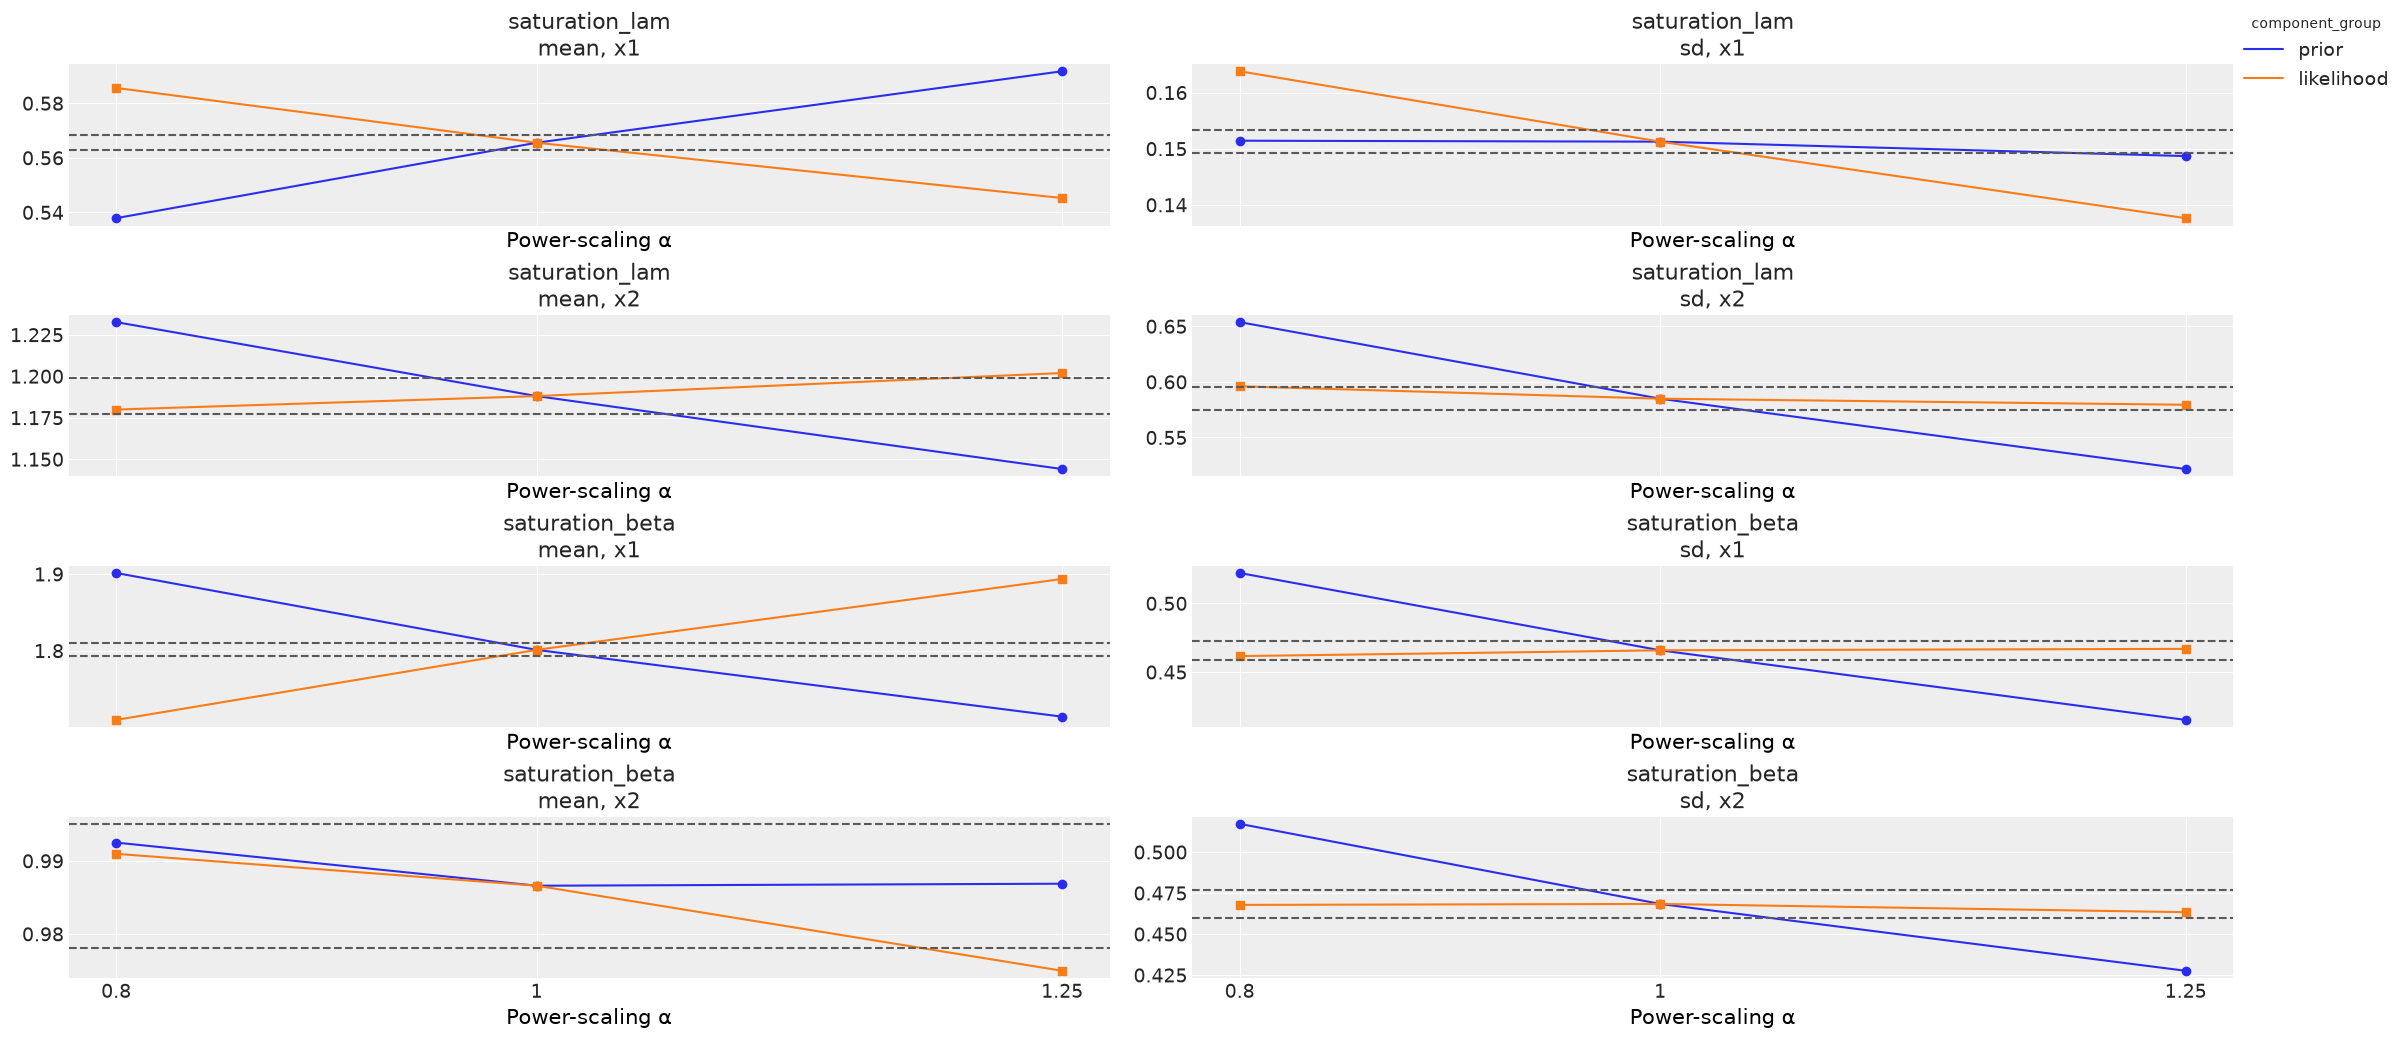

In [18]:
az.plot_psense_quantities(
    business_mmm.idata,
    var_names=["saturation_lam", "saturation_beta"],
    prior_var_names=[
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
    ],
    likelihood_var_names=["y"],
    coords={"channel": ["x1", "x2"]},
    quantities=["mean", "sd"],
)

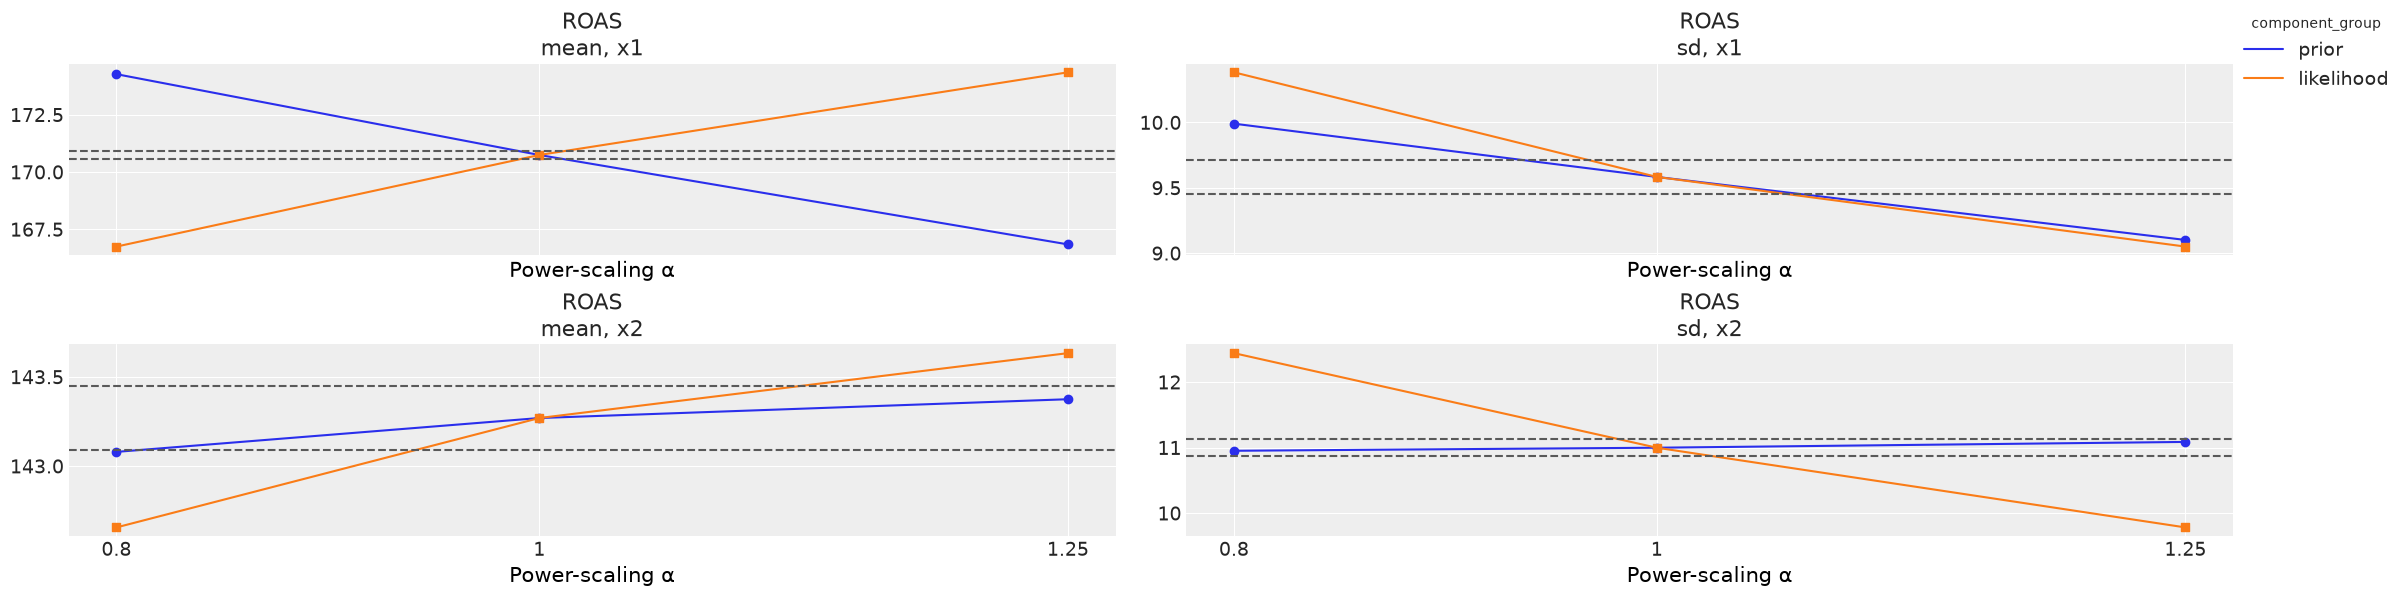

In [19]:
az.plot_psense_quantities(
    business_mmm.idata,
    var_names=["ROAS"],
    prior_var_names=["business_prior"],
    likelihood_var_names=["y"],
    quantities=["mean", "sd"],
)

The saturation-rate and saturation-amplitude parameters are individually sensitive to their priors and to the likelihood, indicating that the observational data do not identify each parameter separately. However, their joint implications are more stable: all-time ROAS remains below the sensitivity threshold for the media, baseline, and seasonality prior blocks.

The remaining decision-relevant conflict is concentrated in `x1` ROAS, which is sensitive to both the stakeholder-informed business prior and the observational likelihood. We cannot resolve that conflict by deciding that either source must be correct. Instead of tuning the model toward either one, we return to the marketing team and recommend lift tests that directly inform the channel response.


## 2. Lift-Test Update: Adding New Evidence

For this synthetic case study, we construct two illustrative lift-test measurements for `x1` at different spend levels from the simulation's data-generating process. They represent the incremental sales that experiments would observe; in a real application, they would come from lift-test analysis. The initial observational model is fitted before introducing these measurements.

Each row below contains pre-test spend `x`, spend change `delta_x`, measured incremental sales `delta_y`, and its uncertainty `sigma`. These measurements add likelihood information anchored to the saturation curve, so we expect the ROAS estimate to become less prior-sensitive.


In [20]:
df_lift_test = pd.DataFrame(
    data={
        "channel": ["x1", "x1"],
        "x": [0.25, 0.8],
        "delta_x": [0.25, 0.8],
        "delta_y": [23.34703279570842, 74.71050494626694],
        "sigma": [3, 3],
        "date": pd.to_datetime(
            [
                X["date"].max() - pd.Timedelta(weeks=50),
                X["date"].max() - pd.Timedelta(weeks=14),
            ]
        ),
    }
)
df_lift_test

,channel,x,delta_x,delta_y,sigma,date
0,x1,0.25,0.25,23.347033,3,2023-04-15
1,x1,0.80,0.80,74.710505,3,2023-12-23


In [21]:
lift_mmm = build_mmm(baseline_model_config)
lift_mmm.build_model(X, y)
lift_mmm.add_lift_test_measurements(df_lift_test=df_lift_test)
lift_mmm = finish_model(
    lift_mmm,
    X,
    y,
    sampler_config=lift_sampler_config,
    business_prior_df=business_prior_df,
)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, y_sigma]


Output()

Output()

Sampling: [business_prior, lift_measurements, y]


Output()

Output()

Output()

### Model Diagnostics

We again verify convergence before interpreting the lift-calibrated model.


In [22]:
convergence_summary(lift_mmm)

divergences        0.0
max_r_hat          1.0
min_ess_bulk    3223.0
min_ess_tail    2923.0
Name: diagnostic, dtype: float64

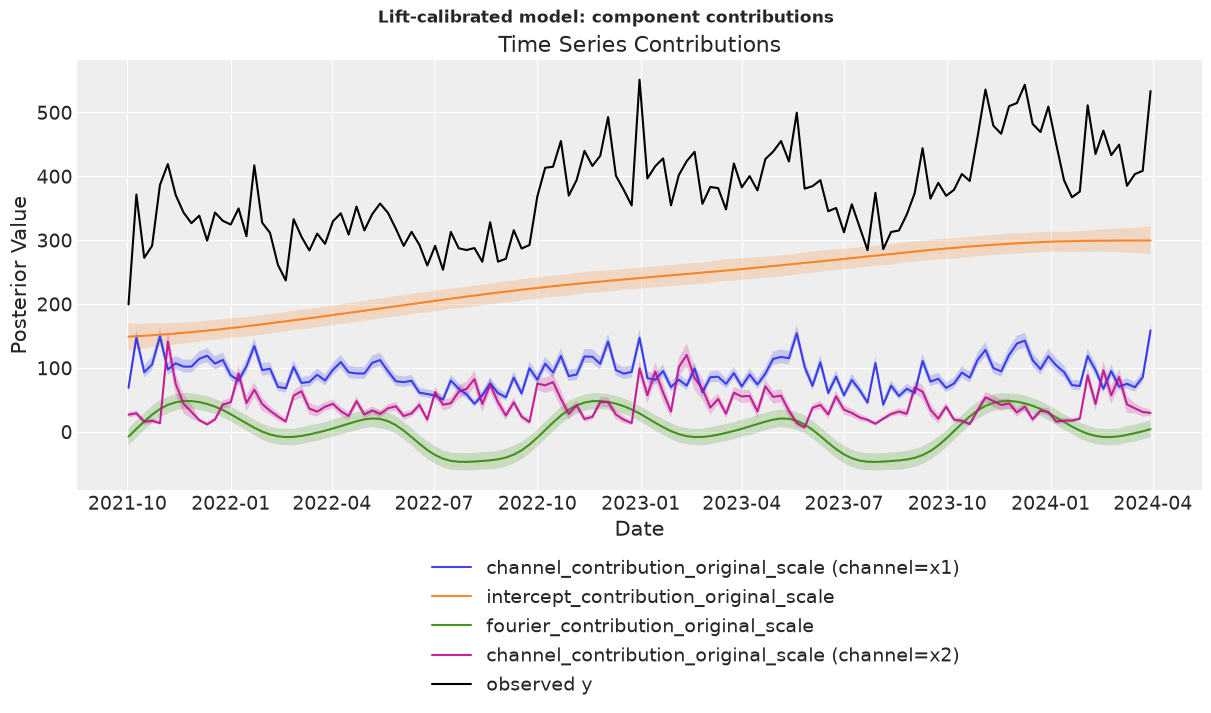

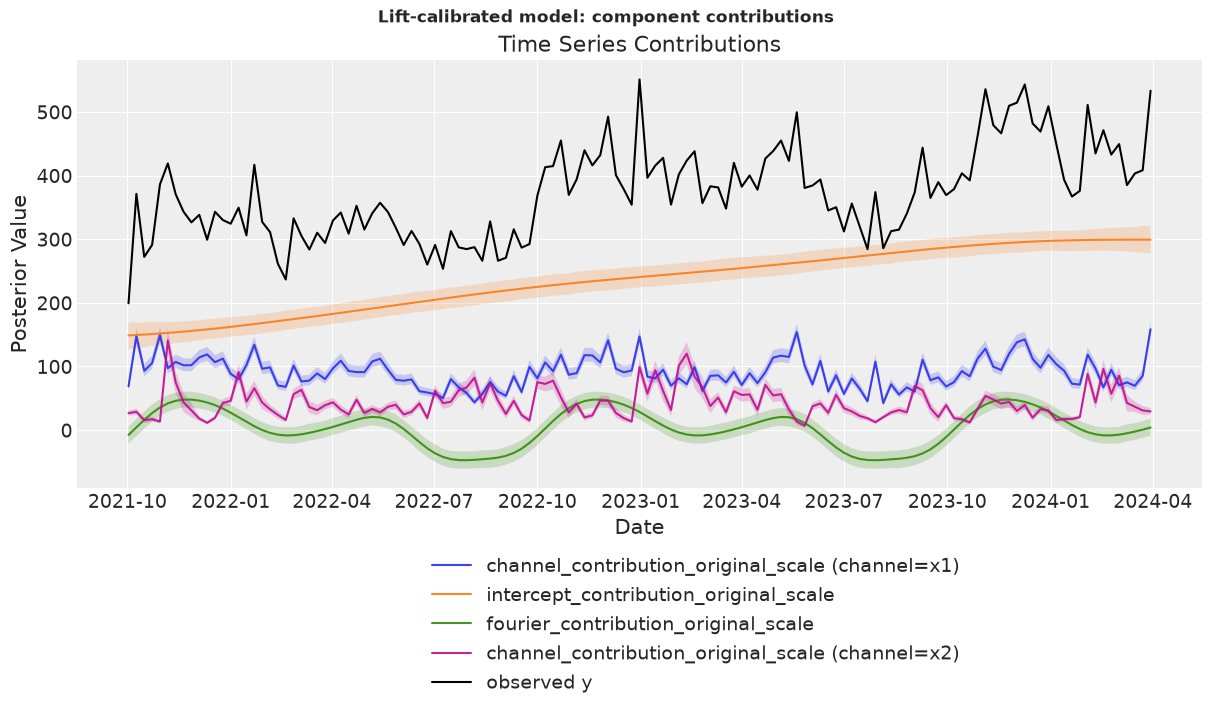

In [23]:
contribution_plot(lift_mmm, model_df, "Lift-calibrated model: component contributions")

In [24]:
pd.concat(
    {
        "observational": roas_summary(business_mmm),
        "lift_calibrated": roas_summary(lift_mmm),
    },
    names=["model"],
)

mean    sd  hdi94_lb  hdi94_ub
model                                                    
observational   ROAS[x1]  170.7   9.6       150       190
                ROAS[x2]  143.3  11.0       120       160
lift_calibrated ROAS[x1]  109.3   5.8       100       120
                ROAS[x2]  142.3  13.8       120       170

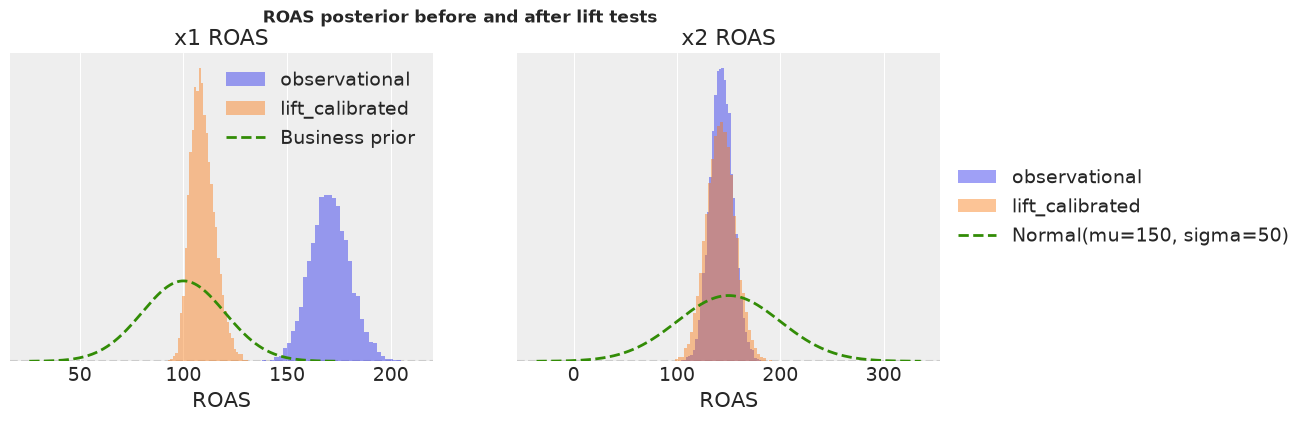

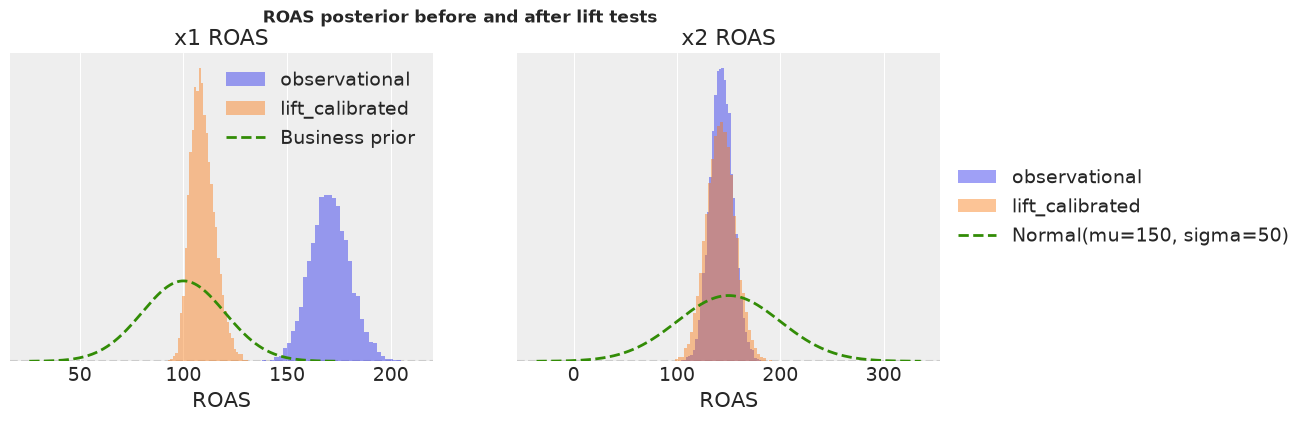

In [25]:
roas_model_comparison = xr.concat(
    [
        business_mmm.idata["posterior"]["ROAS"],
        lift_mmm.idata["posterior"]["ROAS"],
    ],
    dim="model",
).assign_coords(model=["observational", "lift_calibrated"])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
for channel, ax in zip(["x1", "x2"], axes, strict=False):
    for model_name, color in [
        ("observational", "C0"),
        ("lift_calibrated", "C1"),
    ]:
        values = roas_model_comparison.sel(
            model=model_name, channel=channel
        ).values.ravel()
        ax.hist(
            values,
            bins=40,
            density=True,
            alpha=0.45,
            color=color,
            label=model_name,
        )
    if channel == "x1":
        biz_prior_x1.plot_pdf(color="C2", linestyle="--", linewidth=2, ax=ax)
    else:
        biz_prior_x2.plot_pdf(color="C2", linestyle="--", linewidth=2, ax=ax)
    ax.lines[-1].set_label("Business prior")
    ax.set(title=f"{channel} ROAS", xlabel="ROAS")
axes[0].legend()
fig.suptitle("ROAS posterior before and after lift tests", fontweight="bold")
fig

In [26]:
lift_psense_matrix, lift_psense_details = psense_by_target_and_block(lift_mmm.idata)
pd.concat(
    {
        "observational": business_psense_matrix,
        "lift_calibrated": lift_psense_matrix,
    },
    names=["model"],
)

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


media_priors  likelihood  baseline_prior  \
model           posterior_target                                             
observational   ROAS                     0.033       0.272           0.021   
                media_parameters         0.222       0.152           0.021   
                seasonality              0.013       0.164           0.133   
lift_calibrated ROAS                     0.038       0.090           0.016   
                media_parameters         0.197       0.447           0.044   
                seasonality              0.009       0.107           0.117   

                                  business_prior  seasonality_prior  
model           posterior_target                                     
observational   ROAS                       0.255                0.0  
                media_parameters           0.185                0.0  
                seasonality                0.131                0.0  
lift_calibrated ROAS                       0.034                0.0  
                media_parameters           0.029                0.0  
                seasonality                0.006                0.0

In [27]:
def media_prior_details(details):
    return details.query(
        "posterior_target == 'media_parameters' and prior_block == 'media_priors'"
    ).set_index("posterior_variable")[["prior", "likelihood", "diagnosis"]]


pd.concat(
    {
        "observational": media_prior_details(business_psense_details),
        "lift_calibrated": media_prior_details(lift_psense_details),
    },
    names=["model"],
)

prior  likelihood  \
model           posterior_variable                       
observational   adstock_alpha[x1]    0.044       0.113   
                adstock_alpha[x2]    0.020       0.115   
                saturation_lam[x1]   0.134       0.152   
                saturation_lam[x2]   0.145       0.044   
                saturation_beta[x1]  0.222       0.151   
                saturation_beta[x2]  0.127       0.027   
lift_calibrated adstock_alpha[x1]    0.153       0.447   
                adstock_alpha[x2]    0.019       0.106   
                saturation_lam[x1]   0.050       0.054   
                saturation_lam[x2]   0.197       0.054   
                saturation_beta[x1]  0.143       0.086   
                saturation_beta[x2]  0.124       0.033   

                                                                    diagnosis  
model           posterior_variable                                             
observational   adstock_alpha[x1]                                           ✓  
                adstock_alpha[x2]                                           ✓  
                saturation_lam[x1]              potential prior-data conflict  
                saturation_lam[x2]   potential strong prior / weak likelihood  
                saturation_beta[x1]             potential prior-data conflict  
                saturation_beta[x2]  potential strong prior / weak likelihood  
lift_calibrated adstock_alpha[x1]               potential prior-data conflict  
                adstock_alpha[x2]                                           ✓  
                saturation_lam[x1]              potential prior-data conflict  
                saturation_lam[x2]              potential prior-data conflict  
                saturation_beta[x1]             potential prior-data conflict  
                saturation_beta[x2]  potential strong prior / weak likelihood

The observational sales and lift-test measurements together form the likelihood for the updated model. The sales observations alone are confounded, but the lift tests add causal evidence and help correct the resulting ROAS bias. In this case that evidence happens to align with the business prior.

The parameter-level table still contains warnings about potential prior-likelihood conflicts. We do not investigate those warnings further here because this case study focuses on all-time channel ROAS, not on optimizing spend or precisely characterizing each saturation curve. If a decision required the shape of a saturation curve—for example, budget optimization or spend-response planning—we would need additional experiments or external information targeted at identifying that curve.

The reporting target is nevertheless stable: ROAS remains below the practical threshold for the media, baseline, and seasonality prior blocks, while sensitivity to the business prior falls below the threshold. The earlier ROAS prior-likelihood conflict is therefore no longer detected by the power-scaling diagnostic.


## 3. Retrospective Validation and Takeaways

Only now do we reveal the simulation truth.
In real projects this row would not exist; here it checks whether the workflow moved us in the right direction without using the answer key to choose the model.


In [28]:
true_roas_x1 = (raw_df["y"] - raw_df["y01"]).sum() / raw_df["x1"].sum()
true_roas_x2 = (raw_df["y"] - raw_df["y02"]).sum() / raw_df["x2"].sum()
true_roas = DataArray(
    [true_roas_x1, true_roas_x2],
    dims="channel",
    coords={"channel": ["x1", "x2"]},
    name="true_roas",
)

In [29]:
posterior_roas = xr.concat(
    [
        business_mmm.idata["posterior"]["ROAS"],
        lift_mmm.idata["posterior"]["ROAS"],
    ],
    dim="model",
).assign_coords(model=["observational", "lift_calibrated"])

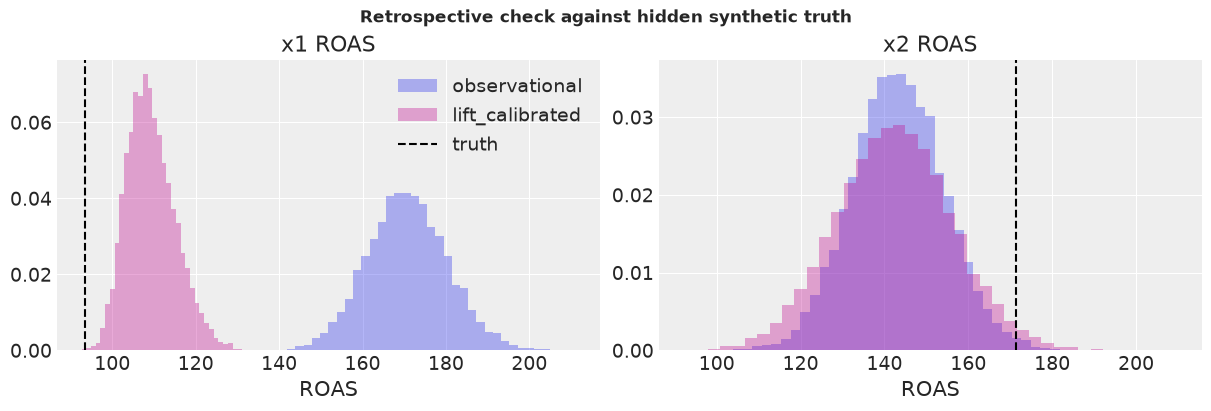

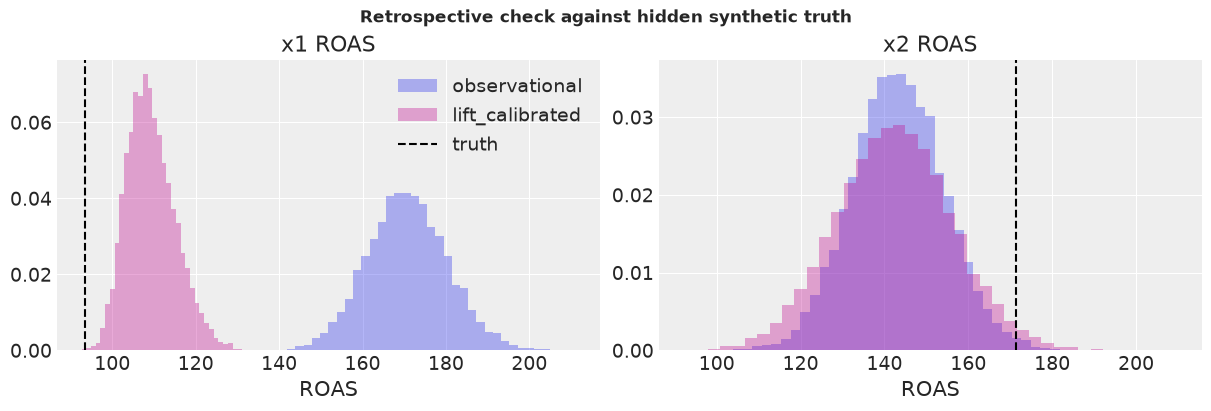

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
for channel, ax in zip(["x1", "x2"], axes, strict=False):
    for model_name, color in [
        ("observational", "C0"),
        ("lift_calibrated", "C3"),
    ]:
        values = posterior_roas.sel(model=model_name, channel=channel).values.ravel()
        ax.hist(
            values,
            bins=40,
            density=True,
            alpha=0.35,
            color=color,
            label=model_name,
        )
    ax.axvline(
        float(true_roas.sel(channel=channel)),
        color="black",
        linestyle="--",
        label="truth",
    )
    ax.set(title=f"{channel} ROAS", xlabel="ROAS")
axes[0].legend()
fig.suptitle("Retrospective check against hidden synthetic truth", fontweight="bold")
fig

**Reporting checklist**

- Define the quantity of interest before fitting; here it is all-time channel ROAS.
- Check prior sensitivity for that quantity after the initial fit, not only generic parameter diagnostics.
- Distinguish sensitivity in internal parameters from sensitivity in the reporting target.
- If the model and business prior disagree, report the conflict and propose evidence that would resolve it.
- Lift tests can add enough causal information that ROAS is no longer materially sensitive to the original prior choices.


## References

- Kallioinen, N., Paananen, T., Bürkner, P.-C., & Vehtari, A. (2024). Detecting and diagnosing prior and likelihood sensitivity with power-scaling. *Statistics and Computing*, 34, 46.
- Vehtari, A., Simpson, D., Gelman, A., Yao, Y., & Gabry, J. (2024). Pareto smoothed importance sampling. *Journal of Machine Learning Research*, 25(72), 1–58.
- PyMC-Marketing ROAS case study: [Mitigating Unobserved Confounders in MMMs with Lift Test Likelihoods](https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_roas.html).
- PyMC-Marketing ROAS calibration case study: [Calibrating an MMM with ROAS Estimates](https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_roas_calibration.html).


In [31]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Mon, 14 Sep 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4
nutpie        : 0.16.11

arviz         : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
preliz        : 0.27.1
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

